# Estimate GHF from basal temperature posterior

In [2]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
import src.model as model
import os
import scipy.io

data_path       = os.getenv('DATA_PATH')
param_path      = os.getenv('PARAM_PATH')
split_data_path = "../data/train-validate-test/" # split data set
folder = data_path
# ------------------------------------------------- LOAD SIMULATION DATA -------------------------------------------------
# get the DATA_PATH from the environment variable
XY_train_filename    = "train_data.npz"
XY_valid_filename    = "validation_data.npz"
XY_test_filename     = "test_data.npz"
H_filename           = 'H_gridded.mat'
Y_obs_filename       = "Ns_obs_gridded.mat"
mask_filename        = 'training_mask.mat' 
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename     = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename      = 'trainingAll_Eb_sim_std.mat'
GHF_mean_filename    = 'trainingAll_GHF_sim_mean.mat'
GHF_std_filename     = 'trainingAll_GHF_sim_std.mat'
# others
coord_filename       = "trainingAll_image_coord.mat"

# preprocessing parameter file: read the csv file
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]
GHF_standardize_epsilon = preprocess_param['GHF_standardization_epsilon'].values[0]
print("Eb_standardize_epsilon:", Eb_standardize_epsilon)
print("GHF_standardize_epsilon:", GHF_standardize_epsilon)

flight_mask_data = scipy.io.loadmat(folder + mask_filename) # this is the flightline mask
H_data           = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename) # this is model domain mask
coord_data       = scipy.io.loadmat(folder + coord_filename)
# standardization data for Eb
Eb_mean          = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std           = scipy.io.loadmat(folder + Eb_std_filename)
GHF_mean         = scipy.io.loadmat(folder + GHF_mean_filename)
GHF_std          = scipy.io.loadmat(folder + GHF_std_filename)

# load
Eb_standardized_train = np.load(split_data_path + XY_train_filename)['Eb_train']
Eb_standardized_valid = np.load(split_data_path + XY_valid_filename)['Eb_validation']
Eb_standardized_test  = np.load(split_data_path + XY_test_filename)['Eb_test']
GHF_standardized_train = np.load(split_data_path + XY_train_filename)['GHF_train']
GHF_standardized_valid = np.load(split_data_path + XY_valid_filename)['GHF_validation']
GHF_standardized_test  = np.load(split_data_path + XY_test_filename)['GHF_test']
# replace nan by 0
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()
GHF_mean = np.nan_to_num(GHF_mean['GHF_mean'], nan=0.0).flatten()
GHF_std  = np.nan_to_num(GHF_std['GHF_std'], nan=0.0).flatten()

# load model boundary
model_bound_data_ori = model_bound_data['in_domain_mask'].astype(bool)

x_coord = coord_data['training_coord'][0][0][0]
y_coord = coord_data['training_coord'][0][0][1]
extent = np.array([x_coord.min(), x_coord.max(), y_coord.max(), y_coord.min()])/1e3 # convert to km (left, right, bottom, top), imshow by default is inverted in y-axis

print('Shape of Eb_standardized_train:', Eb_standardized_train.shape)
print('Shape of GHF_standardized_train:', GHF_standardized_train.shape)
print('Shape of domain mask:', model_bound_data_ori.shape)


Eb_standardize_epsilon: 1287.4819202075
GHF_standardize_epsilon: 0.0181090261526068
Shape of Eb_standardized_train: (256, 256, 1, 833)
Shape of GHF_standardized_train: (256, 256, 1, 833)
Shape of domain mask: (256, 256)


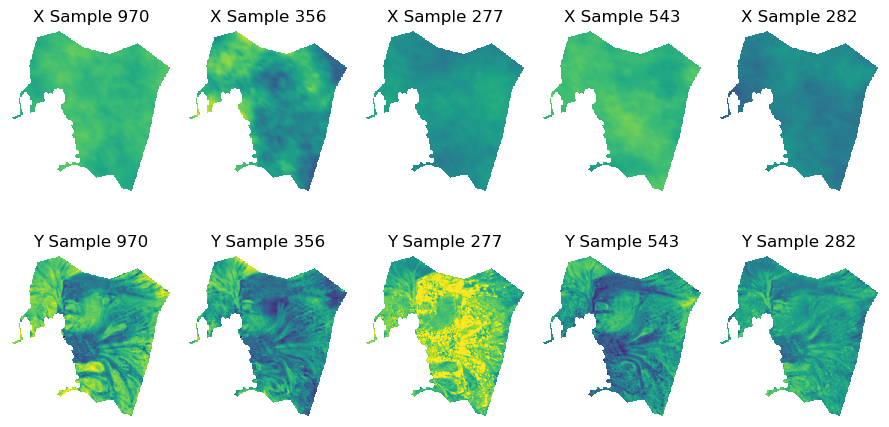

In [3]:
# initialize the model object
md = model.model(extent=extent, coord=(x_coord, y_coord))

# load training data
# first combine all so that our PCA is operated on the whole dataset
Eb_standardized_all = np.concatenate([Eb_standardized_train, 
                                      Eb_standardized_valid, 
                                      Eb_standardized_test], 
                                      axis=3)
GHF_standardized_all = np.concatenate([GHF_standardized_train, 
                                       GHF_standardized_valid, 
                                       GHF_standardized_test], 
                                       axis=3)
md.load_sim_data(GHF_standardized_all, Eb_standardized_all, 
                 domain_mask=model_bound_data_ori, 
                 show_plot=True)

md.load_standardization_data(X_mean=GHF_mean, X_std=GHF_std,
                             Y_mean=Eb_mean, Y_std=Eb_std,
                             X_epsilon=GHF_standardize_epsilon, Y_epsilon=Eb_standardize_epsilon)

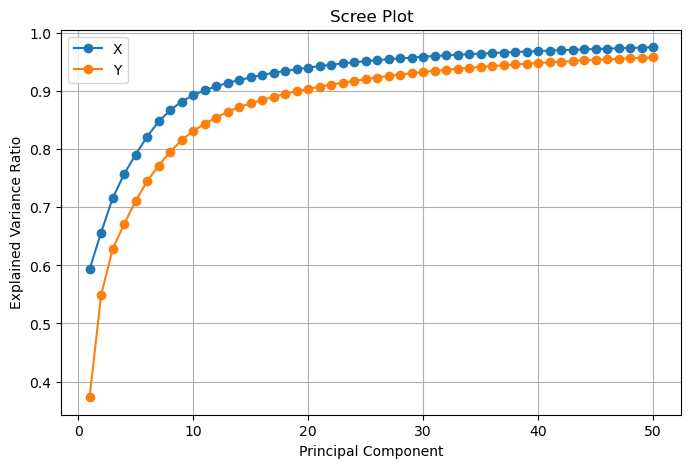

In [3]:
md.pca_scree(n_component_x=50, n_component_y=50)

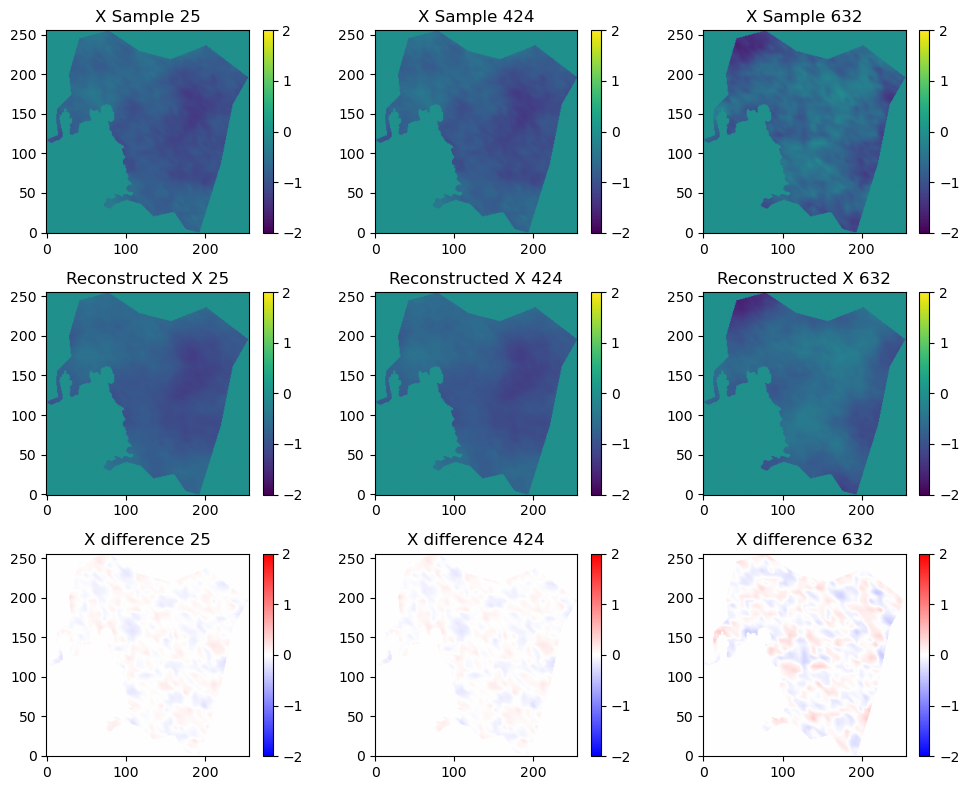

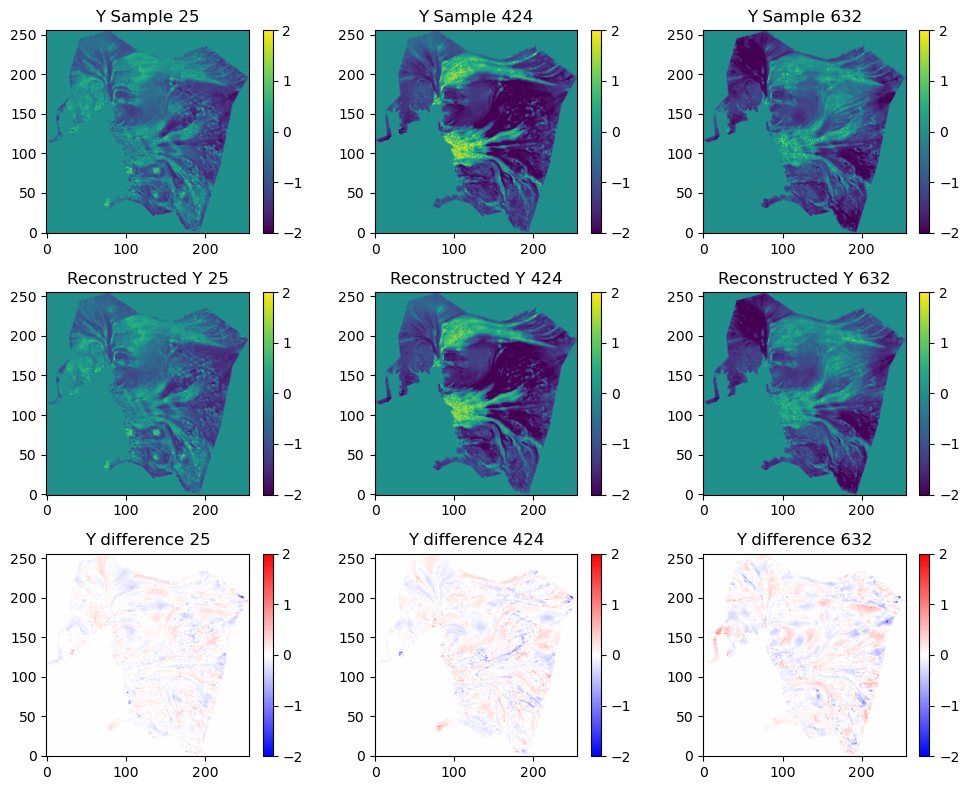

In [37]:
md.pca_recon_inspection(n_component_x=50, n_component_y=50)

In [ ]:
from src.validation import bayesian_information_criterion

# reduce dim with PCA. 
# md.find_reduction_model_pca(n_component_x=20, n_component_y=20)
md.find_reduction_model_pls(n_pca_x=50, n_pca_y=50, n_pls=40)

# load specifically the train, validation, and test (pre-split) data and apply the fitted PLS
md.load_split_data_pls(X_train=GHF_standardized_train, Y_train=Eb_standardized_train,
                       X_val=GHF_standardized_valid, Y_val=Eb_standardized_valid,
                       X_test=GHF_standardized_test, Y_test=Eb_standardized_test)

PCA-PLS joint space shape: (833, 80)


GMM training completed in 0.04 seconds.


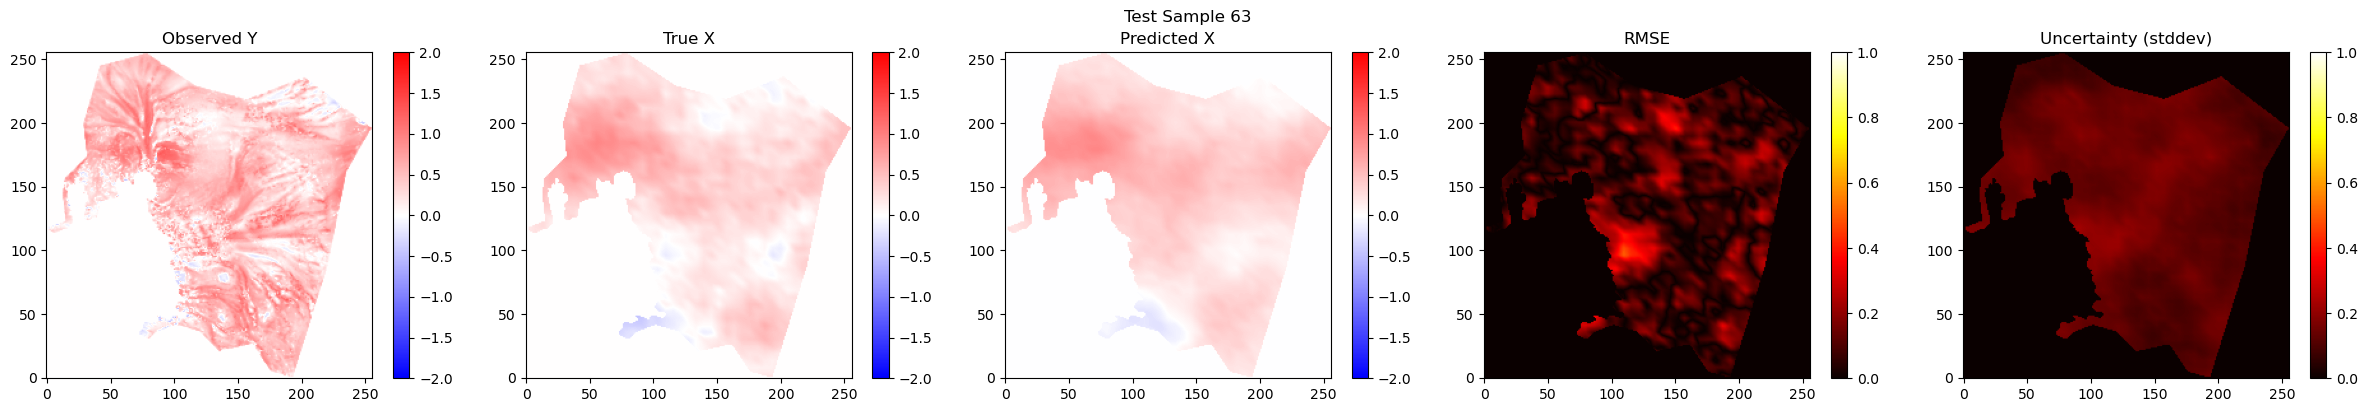

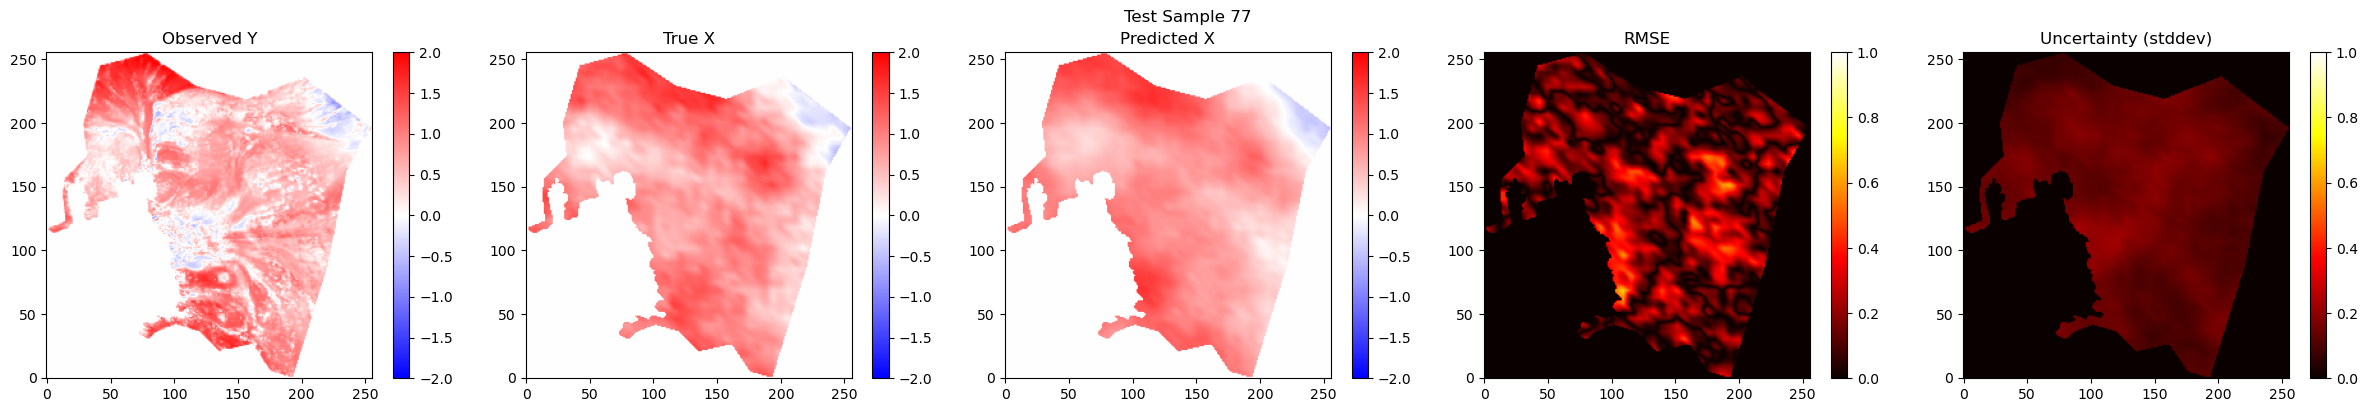

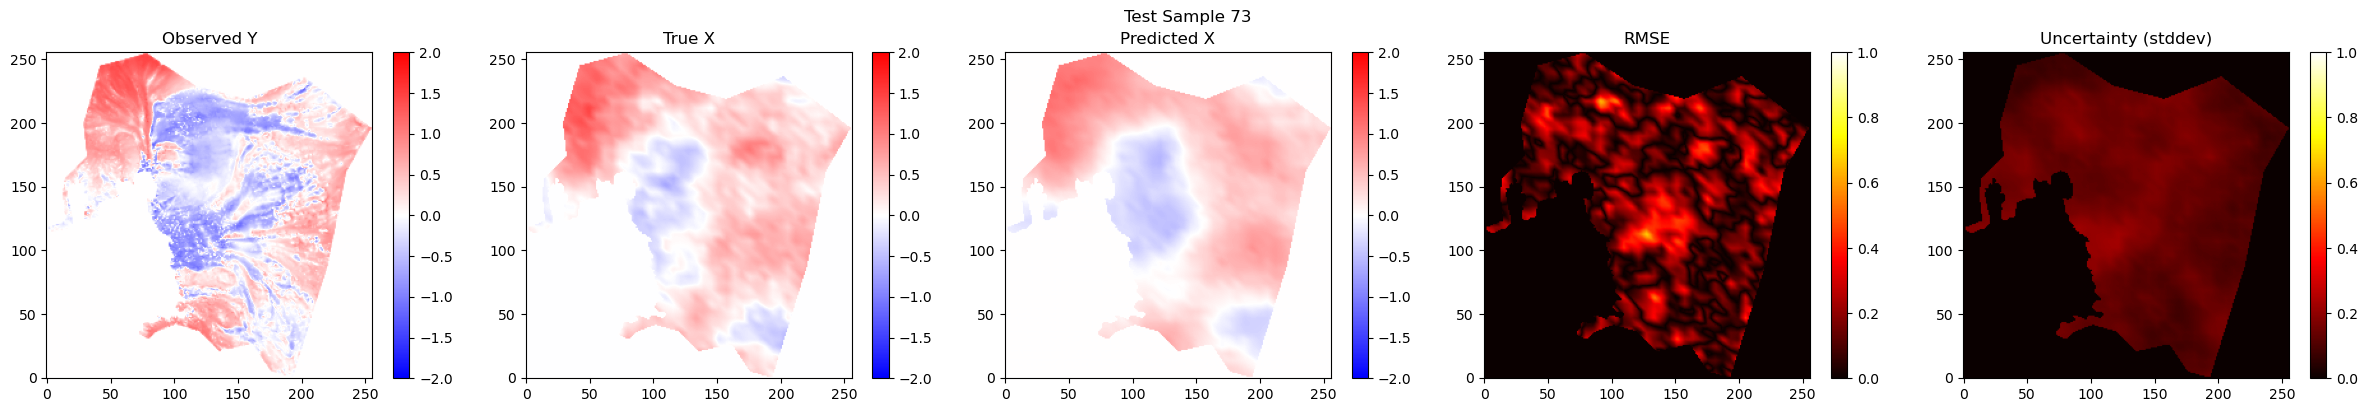

In [42]:
# based on the BIC sweep plot
n_optimal = 3
md.train_gmm_XY(n_components=n_optimal)
md.plot_gmm_samples(n_samples=3)

# Infer on posterior basal enthalpy